In [2]:
#библиотеки
import pandas as pd
import os
import csv
import re
from Bio import SeqIO
import copy
import matplotlib.pyplot as plt
from Bio import Entrez
from Bio.Blast import Applications
import os
from Bio.Blast.Applications import NcbiblastxCommandline


/opt/anaconda3/lib/python3.13/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [3]:
#функция для вытаскивания айдишников из файлов

def get_ids(filename):
    ids = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                id_part = line.split(":")[0]
                ids.append(id_part)
    return ids



In [92]:
notannotCDS_ids = get_ids("Astroviridae_15102025_noannotCDS.txt")
notannotCDS_ids
notannotCDS_target_ids = get_ids("Astroviridae_15102025_noannot_targetCDS.txt")
notannotCDS_target_ids
diff = list(set(notannotCDS_target_ids) - set(notannotCDS_ids))
print(diff)

['MW347540', 'OQ709188', 'OQ709193', 'PQ421843', 'PX395425', 'PQ421852', 'PQ421853', 'PQ421845', 'PQ421842', 'MW645022', 'NC_040647', 'PQ421841', 'OM514376', 'PQ421846', 'PQ421848', 'MN841288', 'MW346737', 'PQ150499', 'MH188020', 'PP211223', 'KX290465', 'PX289196', 'OQ709191', 'OQ709190', 'MT568535', 'MZ182271', 'PQ421844', 'PQ421854', 'MZ443626', 'MW924357', 'MW924356', 'MZ182272', 'MW853972', 'MW645021', 'OQ802761', 'PQ421847', 'OQ709194', 'OQ709189', 'PX289197', 'OP413956', 'MW924358', 'PQ055527', 'PX289198', 'OQ709192', 'MZ291967', 'OP413950', 'PQ161557', 'ON932807']


In [47]:
#превращение tsv файла в csv 
def tsv_to_csv(tsv_path, csv_path):
    df = pd.read_csv(tsv_path, sep="\t")
    df.to_csv(csv_path, index=False)

In [ ]:
#добавление в файл id_prefix (айдишник генома)
def process_files(csv_files):
    result_rows = []
    for csv_file in csv_files:
        result_rows = []
        df = pd.read_csv(csv_file)
        df["ID белка"] = df["ID белка"].astype(str)
        mask1 = df["ID белка"].str.contains("_") & ~df["ID белка"].str.contains("\.")
        df.loc[mask1, "id_prefix"] = df.loc[mask1, "ID белка"].str.split("_").str[0]
        mask2 = df["ID белка"].str.contains(".") & ~df["ID белка"].str.contains("_")
        df.loc[mask2, "id_prefix"] = df.loc[mask2, "ID белка"].str.split(".").str[0]
        result_rows.append(df)
        result = pd.concat(result_rows, ignore_index=True)
        result.to_csv(csv_file, index=False)   
process_files(csv_files)

In [65]:
#скрипт для поиска ORFS
def find_ORFs(csv_files, csv_file_orf, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    orf_df = pd.read_csv(csv_file_orf, header=None).fillna('')
    orf_dict = orf_df.set_index(0)[1].to_dict()
    
    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        all_results = []

        for _, row in df.iterrows():
            description = str(row.get('Описание предсказания', ''))
            matched = False
            if description in orf_dict.keys():
                all_results.append({
                    'ID белка': row.get('ID белка', ''),
                    'Название семейства/белка': row.get('Название семейства/белка', ''),
                    'Описание предсказания': row.get('Описание предсказания', ''),
                    'Источник предсказания': row.get('Источник предсказания', ''),
                    'ORF': orf_dict[description],
                    'id_prefix': row.get('id_prefix', '')
                })
                matched = True

            if not matched:
                all_results.append({
                    'ID белка': row.get('ID белка', ''), 
                    'Название семейства/белка': row.get('Название семейства/белка', ''),
                    'Описание предсказания': row.get('Описание предсказания', ''),
                    'Источник предсказания': row.get('Источник предсказания', ''),
                    'Вхождение из orf': '-',
                    'ORF': '-',
                    'id_prefix': row.get('id_prefix', '')
                })

        results_df = pd.DataFrame(all_results)
        base_name = os.path.basename(csv_file).rsplit(".", 1)[0]
        output_file = os.path.join(output_dir, f"{base_name}_orf_results.csv")
        results_df.to_csv(output_file, index=False)
        print(f"Файл {csv_file} обработан -> {output_file}")


In [66]:
csv_files = ['interpro_выдача/actual_for_191125/output_interpro_new/not_annot_targetCDS_new.csv','interpro_выдача/actual_for_191125/output_interpro_new/not_annot_CDS_nucl_ORFs_merged_output.csv']
csv_file_orf = '../Domain_descriptions.tsv'
output_dir = 'interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try'
find_ORFs(csv_files,csv_file_orf, output_dir)

Файл interpro_выдача/actual_for_191125/output_interpro_new/not_annot_targetCDS_new.csv обработан -> interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_targetCDS_new_orf_results.csv
Файл interpro_выдача/actual_for_191125/output_interpro_new/not_annot_CDS_nucl_ORFs_merged_output.csv обработан -> interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_CDS_nucl_ORFs_merged_output_orf_results.csv


In [105]:
#Добавляем координаты в файл not_annot_CDS (координаты берем из фаста-файла, предсказанного get_orfs())
def add_orf_coords_from_get_orfs(csv_file, fasta_file, output_csv):
    id_to_coords = {}
    id_to_strand = {}

    with open(fasta_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith('>'):
                m = re.match(r'^>(\S+).*?\[(\d+)\s*-\s*(\d+)\]', line)
                if m:
                    protein_id, start, end = m.groups()
                    coords = f"{start}-{end}"
                    id_to_coords.setdefault(protein_id, []).append(coords)
                    strand = "-" if "REVERSE SENSE" in line.upper() else "+"
                    id_to_strand[protein_id] = strand

    with open(csv_file, newline='', encoding='utf-8') as f_in, \
         open(output_csv, 'w', newline='', encoding='utf-8') as f_out:

        reader = csv.DictReader(f_in)
        fieldnames = reader.fieldnames + ['coords', 'strand']
        writer = csv.DictWriter(f_out, fieldnames=fieldnames)
        writer.writeheader()

        for row in reader:
            protein_id = row.get('ID белка', '')
            coords = ','.join(id_to_coords.get(protein_id, []))
            strand = id_to_strand.get(protein_id, '')
            row['coords'] = coords
            row['strand'] = strand
            writer.writerow(row)


In [106]:
add_orf_coords_from_get_orfs(
    csv_file='interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_CDS_nucl_ORFs_merged_output_orf_results.csv',
    fasta_file='interpro_input/not_annot_CDS_nucl_ORFs_after_getorfs.fasta',
    output_csv='interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_CDS_nucl_ORFs_merged_output_orf_result_coords.csv'
)

In [80]:
#Добавляем координаты в файл not_annot_target_CDS (координаты берем из genbank-файла)
def add_cds_coords_from_genbank(csv_file, genbank_file, output_file):
    cds_by_accession = {}

    for record in SeqIO.parse(genbank_file, "genbank"):
        if "accessions" in record.annotations:
            acc = record.annotations["accessions"][0]
        else:
            acc = record.id

        cds_list = []
        for feature in record.features:
            if feature.type == "CDS":
                start = int(feature.location.start) + 1   # GenBank: 0-based start
                end = int(feature.location.end)
                strand = "-" if "(-)" in str(feature.location) else "+"
                cds_list.append((f"{start}-{end}", strand))
        cds_by_accession[acc] = cds_list

    df = pd.read_csv(csv_file)
    def get_coords(raw):
        raw = str(raw).rstrip("|")
        if "." in raw:
            acc, idx = raw.split(".")
        else:
            acc, idx = raw, "1"
        try:
            idx = int(idx)
        except:
            idx = 1
        if acc in cds_by_accession and idx <= len(cds_by_accession[acc]):
            return pd.Series(cds_by_accession[acc][idx - 1])

        return pd.Series(["", ""])

    df[["coords", "strand"]] = df.iloc[:, 0].apply(get_coords)
    df.to_csv(output_file, index=False)



In [82]:
add_cds_coords_from_genbank(
    csv_file='interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_targetCDS_new_orf_results.csv',
    genbank_file="Astroviridae_15102025.gb",
    output_file="interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_targetCDS_new_orf_results_coords.csv"
)

In [117]:
#удаляем строки, где в поле ORFs прочерк
def remove_dash_orf(input_csv, output_csv):
    df = pd.read_csv(input_csv)
    df_clean = df[df['ORF'] != '-']
    df_clean.to_csv(output_csv, index=False)

In [121]:
remove_dash_orf(
    "interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_targetCDS_new_orf_results_coords.csv",
    "interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_targetCDS_final.csv"
)
remove_dash_orf(
    "interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_CDS_nucl_ORFs_merged_output_orf_result_coords.csv",
    "interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_CDS_final.csv"
)

In [173]:
#функция на анализ успешных находок и конфликтов 

def analyze_findings(csv_file, target_ids, output_file):
    valid_orf = {'1A', '1B', '2'}
    df = pd.read_csv(csv_file)

    res = {}
    other = []
    protein_info = {}

    for _, row in df.iterrows():
        orf_val = str(row["ORF"]).strip()
        if orf_val == '-':
            continue

        acc = row["id_prefix"]
        protein_info.setdefault(acc, [])
        protein_info[acc].append({
            "orf": orf_val,
            "coords": row["coords"],
            "strand": row["strand"],
            "ID белка": row.get("ID белка", "")
        })

        if orf_val not in valid_orf:
            other.append({
                "ac": acc,
                "orf": orf_val,
                "coords": row["coords"],
                "strand": row["strand"]
            })
            continue

        row_dict = {orf_val: [row["coords"], row["strand"]]}
        res.setdefault(acc, [])
        if row_dict not in res[acc]:
            res[acc].append(row_dict)

    acc_conflicts = []
    for acc, entries in res.items():
        seen_orf = {}
        seen_coords = {}
        for d in entries:
            (orf, coords) = list(d.items())[0]
            if orf in seen_orf or coords[0] in seen_coords:
                acc_conflicts.append(acc)
            seen_orf[orf] = True
            seen_coords[coords[0]] = True

    acc_conflicts = sorted(set(acc_conflicts))

    rows = []
    acc_successful = []
    for acc, ent in res.items():
        if acc not in acc_conflicts and acc in target_ids:
            acc_successful.append(acc)
            for orf_dict in ent:
                for orf, coord in orf_dict.items():
                    rows.append({
                        "ac": acc,
                        "orf": orf,
                        "Coord": coord[0],
                        "Strand": coord[1]
                    })

    successful_df = pd.DataFrame(rows)

    target_ids = set(target_ids)
    found_ids = set(res.keys())
    not_found = sorted(list(target_ids - found_ids))

    conflict_filtered = [x for x in acc_conflicts if x in target_ids]
    other_filtered = [x for x in other if x["ac"] in target_ids]

    with open(output_file, "w", encoding="utf-8") as f:
        f.write("Конфликтные:\n")
        for acc in conflict_filtered:
            f.write(f"{acc}\n")
            seen = set()
            for item in protein_info[acc]:
                key = (item['ID белка'], item['orf'], item['coords'], item['strand'])
                if key not in seen:
                    seen.add(key)
                    f.write(f"    ID белка={item['ID белка']}, orf={item['orf']}, coords={item['coords']}, strand={item['strand']}\n")

        f.write("\nУспешные:\n")
        for item in acc_successful:
            f.write(f"{item}\n")

        f.write("\nНе найденные:\n")
        for item in not_found:
            f.write(f"{item}\n")

        f.write("\nДругие:\n")
        for item in other_filtered:
            f.write(f"{item}\n")

    return successful_df



In [174]:
csv_file='interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_targetCDS_new_orf_results_coords.csv'
output_file= 'interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/findings_notannot_target_CDS.txt'
df_notannot_target_CDS = analyze_findings(csv_file,diff,output_file)

In [175]:
csv_file='interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_CDS_nucl_ORFs_merged_output_orf_result_coords.csv'
output_file= 'interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/findings_notannot_CDS.txt'
df_notannot_CDS = analyze_findings(csv_file, notannotCDS_ids, output_file)

In [195]:
def write_coords(csv_file, output_file, df):
    df_table = pd.read_csv(csv_file, sep=',', dtype=str)
    first_col = df_table.columns[0]
    df_table[first_col] = df_table[first_col].astype(str).str.strip()
    df['ac'] = df['ac'].astype(str).str.strip()
    for _, row in df.iterrows():
        ac = row['ac'].strip()          
        orf_col = row['orf'].strip()    
        coord = row['Coord'].strip()    
        strand = row.get('Strand', '+').strip()  
        mask = df_table[first_col] == ac
        if mask.any() and orf_col in df_table.columns:
            df_table.loc[mask, orf_col] = coord
            df_table.loc[mask, f'{orf_col}-strand'] = 1 if strand == '+' else -1
        else:
            pass
    df_table = df_table.fillna("NA")
    df_table.to_csv(output_file, index=False, sep=',', encoding='utf-8')
    

In [196]:
csv_file = 'Astroviridae_15102025_orf-coords.csv'
output_file_1 = 'Astroviridae_26112025_1_orf-coords.csv'
write_coords(csv_file, output_file_1, df_notannot_target_CDS)

In [197]:
output_file_2 = 'Astroviridae_26112025_orf-coords.csv'
write_coords(output_file_1, output_file_2, df_notannot_CDS)

In [257]:
#добавляем NA везде, где была пустая ячейка
df = pd.read_csv('Astroviridae_26112025_orf-coords.csv', dtype=str)
df =df.fillna("NA")
df.to_csv('Astroviridae_26112025_orf-coords_filled.csv', index=False, encoding='utf-8')

In [243]:
#скрипт для сравнения файлов с координатами, на выходе файл с различиями + список различающихся id
def compare_files(file1, file2, output_txt='comparison_coords.txt'):
    def read_lines(path):
        with open(path, "r", encoding="utf-8") as f:
            return {line.strip() for line in f if line.strip()}

    lines1 = read_lines(file1)
    lines2 = read_lines(file2)

    only_in_1 = sorted(lines1 - lines2)
    only_in_2 = sorted(lines2 - lines1)
    diff_ids = []
    with open(output_txt, 'w', encoding='utf-8') as f:
        for i in range(max(len(only_in_1), len(only_in_2))):
            x = only_in_1[i]
            x_id = x.split(',')[0]
            diff_ids.append(x_id)
            y = only_in_2[i]
            f.write(f"Строка в первом: {x}\n")
            f.write(f"Строка во втором: {y}\n\n")
    print(diff_ids)
            
file1 = 'Astroviridae_20112025_orf-coords.csv'
file2 = 'Astroviridae_26112025_orf-coords.csv'
compare_files(file1, file2)

['HUANSSPS', 'MH188020', 'MN034422', 'MN034849', 'MT568535', 'MW346737', 'MW347540', 'MW645021', 'MW645022', 'MW853972', 'MW924358', 'MZ182271', 'MZ182272', 'MZ291967', 'MZ443626', 'NC_040647', 'OM514376', 'OQ802761', 'PP211223', 'PQ055527', 'PQ161557', 'PQ421853']


In [245]:
#обрезка фаста-последовательности по координатам (на выходе три файла - 1A, 1B, 2)
def split_genome_and_reverse(input_file, coord_file):
    coord_df = pd.read_csv(coord_file, sep=",", index_col=0)
    orfs = ['1A', '1B', '2']
    #print(coord_df)
    dict_orfs = {}
    for orf in orfs:
        dict_orfs[orf] = list()
    seqs = SeqIO.parse(open(input_file), format='fasta')
    for seq in seqs:
        acc = seq.id.split("_")[0]
        if acc == 'NC' or acc == 'AC':
            acc = '_'.join([acc,seq.id.split("_")[1]])
        for orf in orfs:            
            if (acc in coord_df.index) and (coord_df.loc[acc,orf] != 'NA-NA'):
                cd = coord_df[orf][acc]
                s, e = [int(x) for x in cd.split('-')]
                seq_orf = copy.deepcopy(seq)
                seq_orf.seq = seq.seq[s:e]
                strand_col = f"{orf}-strand"
                if strand_col in coord_df.columns:
                    strand_value = coord_df.loc[acc, strand_col]
                    if strand_value == -1:
                        seq_orf.seq = seq_orf.seq.reverse_complement()
                        seq_orf.id += "_reverse"
                        seq_orf.description = seq_orf.id
                dict_orfs[orf].append(seq_orf)
    out_temp = os.path.splitext(input_file)[0]
    for orf in dict_orfs.keys():
        outfile = out_temp + '_' + orf + '.fasta'
        SeqIO.write(dict_orfs[orf], outfile, "fasta")

In [246]:
input_file = "Astroviridae_15102025.fasta"
coord_file = "Astroviridae_26112025_orf-coords.csv"
split_genome_and_reverse(input_file,coord_file)

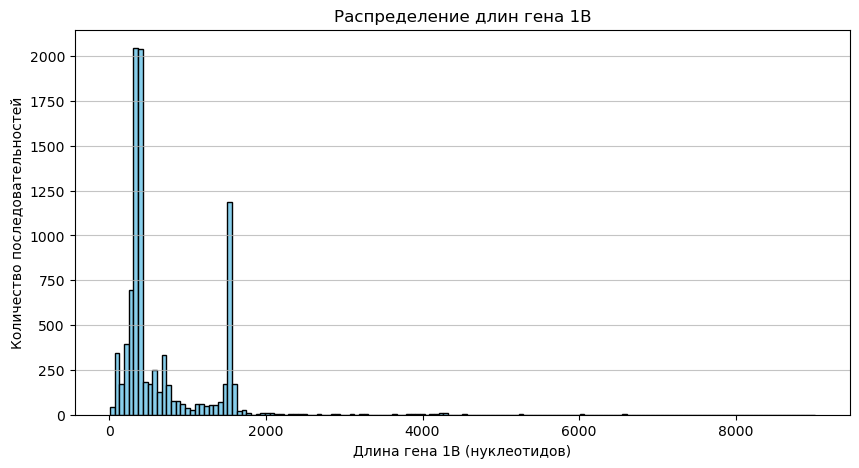

In [27]:
#распределение длин 1B по координатам 
csv_file = 'Astroviridae_26112025_orf-coords.csv'
df = pd.read_csv(csv_file, dtype=str)
df['1B'] = df['1B'].astype(str).str.strip()
def get_length(coord):
    if coord in ["NA-NA", "NA", ""]:
        return None
    try:
        start, end = map(int, coord.split('-'))
        return abs(end - start) + 1
    except:
        return None
        
df['1B_length'] = df['1B'].apply(get_length)
lengths = df['1B_length'].dropna()
long_df = df.loc[df['1B_length'] > 4000, ['GBAC', '1B_length']].sort_values('1B_length', ascending=False)
plt.figure(figsize=(10,5))
plt.hist(lengths, bins=150, color='skyblue', edgecolor='black')
plt.xlabel('Длина гена 1B (нуклеотидов)')
plt.ylabel('Количество последовательностей')
plt.title('Распределение длин гена 1B')
plt.grid(axis='y', alpha=0.75)
plt.show()


In [28]:
from Bio import SeqIO
import pandas as pd

gb_file = 'Astroviridae_15102025.gb'
long_ids = set(long_df['GBAC'].astype(str).str.strip())

definitions = {}

for record in SeqIO.parse(gb_file, "genbank"):
    rec_ids = {record.id}
    if "accessions" in record.annotations:
        rec_ids.update(record.annotations["accessions"])
    intersection = long_ids.intersection(rec_ids)
    if intersection:
        for rid in intersection:
            definitions[rid] = record.description

long_df['definition'] = long_df['GBAC'].map(definitions)
long_df.to_csv("1B_long_records_info.csv", index=False)
print(long_df.head())


          GBAC  1B_length                                         definition
1689  PP172843     9004.0  MAG: Ripikrak virus isolate KCAP1_k141_96123 g...
7587  MN033872     7207.0  MAG: Astroviridae sp. isolate H3_Bulk_Litter_1...
1252  PQ055525     6595.0  MAG: Qianjiang astro-like virus 2 isolate QJ3T...
1677  PP173657     6559.0  MAG: Ripistuv virus isolate MP3_k141_5253 geno...
1250  PQ055527     6270.0  MAG: Qianjiang astro-like virus 4 isolate QJ3T...


In [255]:
Entrez.email = "adelina.kzn15@gmail.com"

for acc in ["PQ421852", "PQ421844"]:
    with Entrez.efetch(db="nuccore", id=acc, rettype="fasta", retmode="text") as handle:
        seq = handle.read()
    with open(f"{acc}.fasta", "w") as f:
        f.write(seq)

In [263]:
#ручная вставка координат
df = pd.read_csv("Astroviridae_26112025_orf-coords.csv",dtype=str)
key = "PQ421852"
new_values = ["3613-5013", str(-1), "2240-3322", str(-1), "11-1798", str(-1)]

df.loc[df['GBAC'] == key, df.columns[1:]] = [new_values]

df.to_csv("Astroviridae_26112025_orf-coords_new.csv", index=False)
